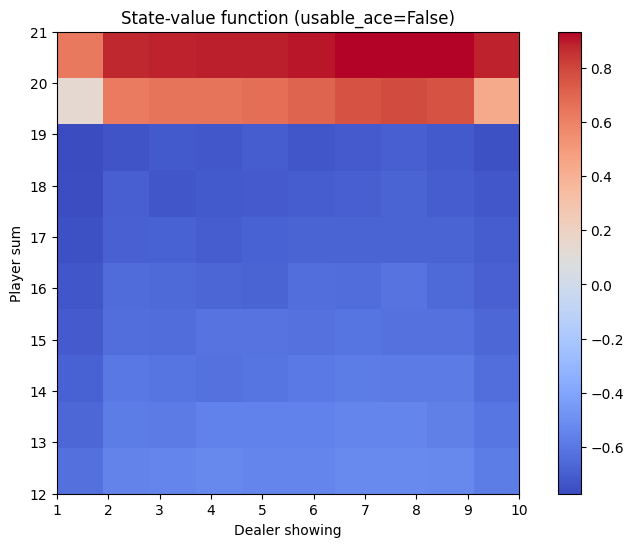

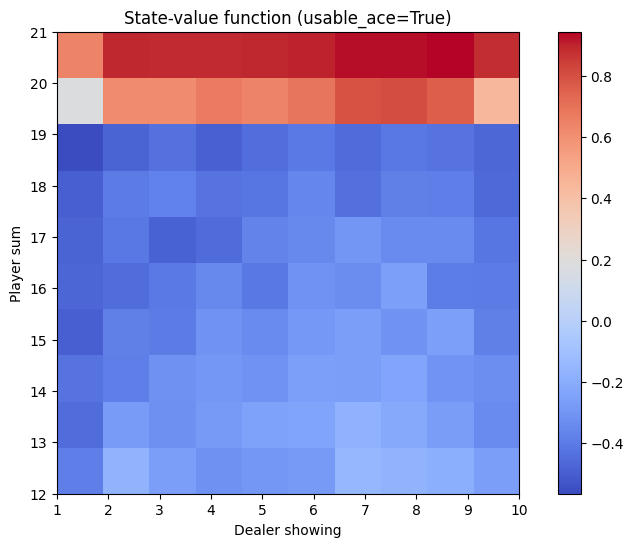

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Tạo môi trường Blackjack (phiên bản chuẩn)
env = gym.make('Blackjack-v1', natural=False, sab=False)

# Chính sách: Stick nếu tổng >= 20, còn lại Hit
def policy(state):
    player_sum, dealer_card, usable_ace = state
    return 0 if player_sum >= 20 else 1  # 0: stick, 1: hit

# First-visit Monte Carlo Prediction
def mc_prediction(policy, env, num_episodes, gamma=1.0):
    V = defaultdict(float)
    returns = defaultdict(list)
    for _ in range(num_episodes):
        episode = []
        state, _ = env.reset()
        done = False
        while not done:
            action = policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state
        # Tính return cho mỗi trạng thái lần đầu tiên xuất hiện
        states_in_episode = set([x[0] for x in episode])
        for s in states_in_episode:
            first_occ = next(i for i, x in enumerate(episode) if x[0] == s)
            G = sum(x[2] * (gamma ** i) for i, x in enumerate(episode[first_occ:]))
            returns[s].append(G)
            V[s] = np.mean(returns[s])
    return V

# Chạy với 500,000 episode (có thể giảm xuống 100,000 nếu máy chậm)
V = mc_prediction(policy, env, 500000)

# Hàm vẽ value function
def plot_value_function(V, usable_ace=False):
    dealer_range = range(1, 11)
    player_range = range(12, 22)
    Z = np.zeros((len(player_range), len(dealer_range)))
    for i, p in enumerate(player_range):
        for j, d in enumerate(dealer_range):
            Z[i, j] = V.get((p, d, usable_ace), 0)
    plt.figure(figsize=(10, 6))
    plt.imshow(Z, origin='lower', extent=[1, 10, 12, 21], cmap='coolwarm')
    plt.colorbar()
    plt.xlabel("Dealer showing")
    plt.ylabel("Player sum")
    plt.title(f"State-value function (usable_ace={usable_ace})")
    plt.show()

# Vẽ hai trường hợp: có ace linh hoạt và không
plot_value_function(V, usable_ace=False)
plot_value_function(V, usable_ace=True)